# MovieChat, reproduced: dense tokens → sparse memory

Reproduction of the core memory-efficiency claim of
**MovieChat: From Dense Token to Sparse Memory for Long Video Understanding**
([arXiv:2307.16449](https://arxiv.org/abs/2307.16449)).

**The claim.** A video pipeline that keeps every frame's tokens grows linearly and
runs out of VRAM on long videos. MovieChat's short-term FIFO + consolidated
long-term memory stays **flat regardless of video length** — using a merge rule
that is parameter-free and training-free.

**Two experiments.**

1. **Scaling** — push 100 → 10,000 frames through a naive pipeline and through the
   MovieChat memory manager; measure what each is holding.
2. **Consolidation** — run a *real* pretrained ViT-B/16 over frames with clear scene
   cuts and check that the frames it threw away were the redundant ones.

Every number in this notebook is produced by running the cells below. Nothing is
hardcoded or copied in from the paper.

## 0. Setup

Environment: Apple M5, 24 GB unified memory, torch on MPS, **no CUDA**. That shapes
how memory is measured — see §1.

In [1]:
import gc, json, time
from dataclasses import dataclass, field
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import psutil
import timm
import torch
import torch.nn.functional as F
from matplotlib.ticker import FuncFormatter
from skimage.metrics import structural_similarity as ssim

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

MB, GB = 1024.0**2, 1024.0**3
FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)
RESDIR = Path("results"); RESDIR.mkdir(exist_ok=True)

def device_report():
    if torch.cuda.is_available():
        return f"CUDA available: {torch.cuda.get_device_name(0)} -- VRAM figures are real."
    if torch.backends.mps.is_available():
        return ("CUDA NOT available. Apple Silicon (MPS). No VRAM counter exists; "
                "process RSS is reported instead and is labelled as such.")
    return "CUDA NOT available. Running on CPU."

print(device_report())
print("torch", torch.__version__)

/Users/atharvax/dev/til/papers/LLVM/MovieChat/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA NOT available. Apple Silicon (MPS). No VRAM counter exists; process RSS is reported instead and is labelled as such.
torch 2.5.1


## 1. Measurement — three different things, never mixed

This is the part that decides whether the result means anything, so it goes first.

| metric | what it is | status here |
|---|---|---|
| **stored token memory** | `n_tokens × D × 4 B` (float32) — the size of the token buffer a pipeline is holding | **primary.** Exact, deterministic, machine-independent |
| **CUDA `max_memory_allocated`** | real VRAM high-water mark | **n/a** — no CUDA device on this machine. Never substituted for |
| **process RSS** | resident set size of the whole Python process | secondary sanity line only. Includes interpreter, torch, allocator slack. **Not VRAM** |

The primary metric is arithmetic over what the pipeline actually retains. Below it is
checked against the *real* allocated tensor bytes, so it isn't taken on faith.

In [2]:
def token_bytes(n_frames, tokens_per_frame, dim, bytes_per_elem=4):
    """Exact size of a stored token buffer, in bytes. The primary metric."""
    return int(n_frames) * int(tokens_per_frame) * int(dim) * int(bytes_per_elem)

def sum_tensor_bytes(tensors):
    """Ground-truth byte count of tensors a pipeline is genuinely holding."""
    return int(sum(t.numel() * t.element_size() for t in tensors))

def process_rss():
    """Resident set size in bytes. NOT VRAM."""
    return int(psutil.Process().memory_info().rss)

def cuda_max_allocated():
    return int(torch.cuda.max_memory_allocated()) if torch.cuda.is_available() else None

def frames_to_cross(budget_bytes, tokens_per_frame, dim, bytes_per_elem=4):
    """Frames a keep-everything pipeline needs to reach a byte budget."""
    return budget_bytes / (tokens_per_frame * dim * bytes_per_elem)

LABEL_TOKENS = "Stored token memory (MB)"
LABEL_RSS    = "process RSS (not VRAM) (MB)"
LABEL_CUDA   = "CUDA max_memory_allocated (MB)"

## 2. Encoders — strictly frame-by-frame, no temporal mixing

Two modes.

**`SyntheticEncoder`** — deterministic seeded token tensors with an explicit redundancy
structure: runs of near-identical frames punctuated by scene cuts. No pixels, no network.
It exists so the 10,000-frame sweep in §5 finishes in seconds. Labelled SYNTHETIC wherever
it is used.

**`RealEncoder`** — a pretrained timm ViT-B/16 at 224×224 run independently on each frame,
then squeezed to 32 tokens of dim 256.

### What `QFormerSqueeze` is, and is not

It reproduces the *shape* of BLIP-2's Q-former bottleneck (197×768 dense → 32×256 sparse),
not its semantics:

- The **pooling is real** — 32 fixed query vectors cross-attend over the frame's ViT patch
  tokens, so every output token is a convex combination of genuine pretrained features.
  Frame-to-frame cosine geometry still reflects real image content.
- The **projection** is a fixed, seeded, near-orthogonal random matrix (768→256). Random
  projections approximately preserve cosine distance (Johnson–Lindenstrauss).
- It is **untrained**, and it is **not** BLIP-2's Q-former.

The memory claim depends on the token-count bottleneck, which is exact. §6 relies on
similarity structure surviving the squeeze — and measures whether it did.

In [3]:
VIT_B16_TOKENS, VIT_B16_DIM = 197, 768   # 14x14 patches + CLS, width 768

class QFormerSqueeze(torch.nn.Module):
    """(P, 768) ViT patch tokens -> (Q, D). Untrained stand-in; see markdown above."""
    def __init__(self, in_dim=VIT_B16_DIM, n_query=32, out_dim=256, seed=0):
        super().__init__()
        g = torch.Generator().manual_seed(seed)
        self.register_buffer("queries", F.normalize(torch.randn(n_query, in_dim, generator=g), dim=-1))
        q_, _ = torch.linalg.qr(torch.randn(in_dim, out_dim, generator=g))
        self.register_buffer("proj", q_[:, :out_dim].contiguous())
        self.scale = in_dim ** -0.5

    @torch.no_grad()
    def forward(self, patch_tokens):
        q = self.queries.to(patch_tokens.dtype)
        attn = torch.softmax(patch_tokens @ q.t() * self.scale, dim=1)   # (B, P, Q)
        pooled = attn.transpose(1, 2) @ patch_tokens                      # (B, Q, in_dim)
        return pooled @ self.proj.to(patch_tokens.dtype)


class RealEncoder:
    """Pretrained image ViT applied independently to each frame."""
    kind = "real"

    def __init__(self, model_name="vit_base_patch16_224", tokens_per_frame=32,
                 dim=256, seed=0, pretrained=True):
        self.device = torch.device(
            "cuda" if torch.cuda.is_available()
            else "mps" if torch.backends.mps.is_available() else "cpu")
        self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        self.model.eval().to(self.device)
        self.model_name, self.pretrained = model_name, pretrained

        cfg = timm.data.resolve_data_config({}, model=self.model)
        self.mean = torch.tensor(cfg["mean"]).view(1, 3, 1, 1).to(self.device)
        self.std = torch.tensor(cfg["std"]).view(1, 3, 1, 1).to(self.device)
        self.input_size = cfg["input_size"][-1]
        self.tokens_per_frame, self.dim = tokens_per_frame, dim
        self.squeeze = QFormerSqueeze(self.model.num_features, tokens_per_frame, dim, seed).to(self.device)

    @property
    def dense_tokens_per_frame(self):
        return self.model.patch_embed.num_patches + self.model.num_prefix_tokens

    @property
    def dense_dim(self):
        return self.model.num_features

    @torch.no_grad()
    def encode(self, frames_uint8, dense=False, batch_size=16):
        """(T,H,W,3) uint8 RGB -> (T, tokens, dim) float32 on CPU.

        batch_size only controls how many independent frames share a forward pass;
        a ViT never mixes across the batch dimension, so there is no temporal leakage.
        """
        out = []
        for i in range(0, len(frames_uint8), batch_size):
            x = torch.from_numpy(np.ascontiguousarray(frames_uint8[i:i + batch_size])).to(self.device)
            x = x.permute(0, 3, 1, 2).float() / 255.0
            if x.shape[-1] != self.input_size:
                x = F.interpolate(x, size=(self.input_size,) * 2, mode="bilinear", align_corners=False)
            x = (x - self.mean) / self.std
            tok = self.model.forward_features(x)
            out.append((tok if dense else self.squeeze(tok)).float().cpu())
        return torch.cat(out, dim=0)

    def describe(self):
        w = "pretrained" if self.pretrained else "RANDOM-INIT"
        return (f"REAL encoder: timm {self.model_name} ({w}), {self.input_size}px, "
                f"device={self.device.type}; dense={self.dense_tokens_per_frame}x{self.dense_dim}, "
                f"squeezed={self.tokens_per_frame}x{self.dim}")


@dataclass
class SyntheticEncoder:
    """Seeded token streams: runs of near-identical frames + scene cuts. SYNTHETIC."""
    tokens_per_frame: int = 32
    dim: int = 256
    scene_length: int = 40
    jitter: float = 0.05
    seed: int = 0
    kind: str = "synthetic"

    def encode_stream(self, n_frames, batch=4096):
        """Streamed, so a 10k sweep never materialises the video beside the buffers."""
        g = torch.Generator().manual_seed(self.seed)
        produced, base = 0, None
        while produced < n_frames:
            k = min(batch, n_frames - produced)
            chunk = torch.empty(k, self.tokens_per_frame, self.dim)
            for j in range(k):
                if (produced + j) % self.scene_length == 0 or base is None:
                    base = torch.randn(self.tokens_per_frame, self.dim, generator=g)
                chunk[j] = base + self.jitter * torch.randn(self.tokens_per_frame, self.dim, generator=g)
            yield chunk
            produced += k

    def encode(self, n_frames):
        return torch.cat(list(self.encode_stream(n_frames)), dim=0)

    def describe(self):
        return (f"SYNTHETIC encoder (no pixels/network): {self.tokens_per_frame}x{self.dim} tokens/frame, "
                f"scene_length={self.scene_length}, jitter={self.jitter}, seed={self.seed}")

Quick check that the synthetic stream has the redundancy structure it claims: frames inside
a scene should be nearly identical, frames across a cut should be unrelated.

In [4]:
_enc = SyntheticEncoder(seed=SEED)
_X = _enc.encode(82)
_sims = F.cosine_similarity(_X[:-1], _X[1:], dim=-1).mean(dim=-1).numpy()
_cut = [i for i in range(len(_sims)) if (i + 1) % _enc.scene_length == 0]
_within = [i for i in range(len(_sims)) if i not in _cut]
print(_enc.describe())
print(f"within a scene : mean cosine {_sims[_within].mean():+.4f}")
print(f"across a cut   : {[f'{_sims[i]:+.4f}' for i in _cut]}")

SYNTHETIC encoder (no pixels/network): 32x256 tokens/frame, scene_length=40, jitter=0.05, seed=0
within a scene : mean cosine +0.9975
across a cut   : ['+0.0123', '-0.0126']


## 3. Baseline — the pipeline that keeps everything

Encode every frame, append its tokens, never drop or merge. Stored memory is exactly
linear in frame count.

One practical wrinkle: this machine has 24 GB of RAM *total*, and the whole point of the
experiment is that this pipeline exceeds that. So physical allocation stops at a guard
(`max_materialize_bytes`), while **exact accounting continues**. `materialization_truncated_at`
records where that happened so it is never confused with a gap in the measurement.

In [5]:
class NaiveDenseMemory:
    """Append-only token store. Keeps every frame."""
    name = "naive-dense"

    def __init__(self, tokens_per_frame=32, dim=256, materialize=True,
                 max_materialize_bytes=2 * 1024**3):
        self.tokens_per_frame, self.dim = tokens_per_frame, dim
        self.materialize, self.max_materialize_bytes = materialize, max_materialize_bytes
        self._store, self._n_frames = [], 0
        self.materialization_truncated_at = None

    @property
    def will_materialize(self):
        """Lets a caller skip generating a tensor it is only going to drop."""
        if not self.materialize:
            return False
        return (self.max_materialize_bytes is None
                or self.stored_token_bytes < self.max_materialize_bytes)

    def add_frame(self, x):
        self._n_frames += 1
        if not self.will_materialize or x is None:
            if self.materialize and self.materialization_truncated_at is None:
                self.materialization_truncated_at = self._n_frames
            return
        self._store.append(x.detach().to(torch.float32).contiguous())

    def add_frames(self, xs):
        for i in range(xs.shape[0]):
            self.add_frame(xs[i])

    stored_frames      = property(lambda s: float(s._n_frames))
    stored_tokens      = property(lambda s: s._n_frames * s.tokens_per_frame)
    stored_token_bytes = property(lambda s: token_bytes(s._n_frames, s.tokens_per_frame, s.dim))

    def all_tensors(self):
        return list(self._store)

    def describe(self):
        return (f"{self.name}: keeps every frame, {self.tokens_per_frame}x{self.dim}, "
                f"{token_bytes(1, self.tokens_per_frame, self.dim) / 1024:.1f} KiB/frame")

## 4. MovieChat memory — Algorithm 1

Straight from the paper (§3.3–3.4):

```
Require: S (short-term memory)
while len(S) > R_L do
    for x_i in S:  s_i = sim(x_i, x_{i+1})      # token similarity
    m = argmax(s)                               # maximum value index
    x_m = merge(x_m, x_{m+1})                   # merge
    del x_{m+1}
```

with the frame-pair similarity of **Eq. 3** — the mean over the *N* tokens of the per-token
cosine:

$$s = \frac{1}{N}\sum_{j=1}^{N}\cos\left(x_i^j,\ x_{i+1}^j\right)$$

`merge` is a **ToMe-style size-weighted average**, so a frame standing for 40 originals is
not outvoted by a fresh one. The whole mechanism is two operations — cosine similarity and
weighted averaging. No parameters, no training.

Similarities are cached and only the two pairs adjoining a merge are recomputed, which keeps
consolidation cheap enough to run on every overflow.

**Two documented deviations from the paper**, both exposed as arguments:

- **Long-term cap.** The paper extends positional encodings rather than capping `L`. Capping
  is what makes memory *provably* flat, so `L` is capped and overflow re-runs the same
  parameter-free merge over `L`.
- **Short-term re-init.** Paper §3.3 re-initialises `S` with the consolidated feature so
  information crosses window boundaries. Default here clears `S`; `reinit_short_term=True`
  restores the paper's behaviour. It changes consolidation cadence, not the bound.

In [6]:
def frame_pair_similarity(a, b):
    """Eq. 3: mean over the N tokens of the per-token cosine similarity."""
    return float(F.cosine_similarity(a, b, dim=-1).mean())

def adjacent_similarities(frames):
    if len(frames) < 2:
        return []
    st = torch.stack(frames)
    return F.cosine_similarity(st[:-1], st[1:], dim=-1).mean(dim=-1).tolist()


@dataclass
class MergeEvent:
    similarity: float
    kept_index: int
    dropped_index: int
    kept_sources: list
    dropped_sources: list
    stage: str


@dataclass
class _Frames:
    """Frames plus ToMe sizes and source provenance."""
    tokens: list = field(default_factory=list)
    sizes: list = field(default_factory=list)
    sources: list = field(default_factory=list)

    def __len__(self):
        return len(self.tokens)

    def append(self, t, size, src):
        self.tokens.append(t); self.sizes.append(size); self.sources.append(src)

    def extend(self, o):
        self.tokens.extend(o.tokens); self.sizes.extend(o.sizes); self.sources.extend(o.sources)


def greedy_merge(frames, target, stage, log=None):
    """Algorithm 1: repeatedly merge the most-similar adjacent pair."""
    if len(frames) <= target:
        return frames
    toks, sizes = list(frames.tokens), list(frames.sizes)
    srcs = [list(s) for s in frames.sources]
    sims = adjacent_similarities(toks)

    while len(toks) > target:
        m = max(range(len(sims)), key=sims.__getitem__)
        wa, wb = sizes[m], sizes[m + 1]
        merged = (toks[m] * wa + toks[m + 1] * wb) / (wa + wb)   # size-weighted (ToMe)

        if log is not None:
            log.append(MergeEvent(sims[m], m, m + 1, list(srcs[m]), list(srcs[m + 1]), stage))

        toks[m], sizes[m], srcs[m] = merged, wa + wb, srcs[m] + srcs[m + 1]
        del toks[m + 1], sizes[m + 1], srcs[m + 1]

        # Only the pairs adjoining the merged slot changed.
        del sims[m]
        if m < len(sims):
            sims[m] = frame_pair_similarity(toks[m], toks[m + 1])
        if m > 0:
            sims[m - 1] = frame_pair_similarity(toks[m - 1], toks[m])

    out = _Frames(); out.tokens, out.sizes, out.sources = toks, sizes, srcs
    return out

In [7]:
class MovieChatMemory:
    """Fixed short-term FIFO feeding a capped, consolidated long-term memory."""
    name = "moviechat"

    def __init__(self, window=16, short_term_frames=18, tokens_per_frame=32, dim=256,
                 long_term_frames=256, consolidation_length=2,
                 reinit_short_term=False, track_merges=False):
        self.window = window                       # non-overlap sliding window (Eq. 1)
        self.K = short_term_frames                 # FIFO capacity
        self.R_L = consolidation_length            # frames kept per consolidation
        self.L_cap = long_term_frames              # cap on L
        self.tokens_per_frame, self.dim = tokens_per_frame, dim
        self.reinit_short_term = reinit_short_term

        self.short_term, self.long_term = _Frames(), _Frames()
        self.merge_log = [] if track_merges else None
        self._n_ingested = self.n_consolidations = self.n_compactions = 0

    def add_frame(self, x):
        self.short_term.append(x.detach().to(torch.float32).contiguous(), 1.0, [self._n_ingested])
        self._n_ingested += 1
        if len(self.short_term) > self.K:
            self._consolidate()

    def add_frames(self, xs):
        for i in range(xs.shape[0]):
            self.add_frame(xs[i])

    def _consolidate(self):
        """Pop S, merge down to R_L frames, push into L."""
        merged = greedy_merge(self.short_term, self.R_L, "short-term-consolidation", self.merge_log)
        self.n_consolidations += 1
        self.long_term.extend(merged)
        self.short_term = _Frames()
        if self.reinit_short_term:
            for t, s, src in zip(merged.tokens, merged.sizes, merged.sources):
                self.short_term.append(t, s, list(src))
        self._compact_long_term()

    def _compact_long_term(self):
        if len(self.long_term) <= self.L_cap:
            return
        self.long_term = greedy_merge(self.long_term, self.L_cap, "long-term-compaction", self.merge_log)
        self.n_compactions += 1

    def finalize(self):
        """Flush whatever is left in S. Call once after the last frame."""
        if len(self.short_term):
            self._consolidate()

    stored_frames      = property(lambda s: float(len(s.short_term) + len(s.long_term)))
    stored_tokens      = property(lambda s: int(s.stored_frames) * s.tokens_per_frame)
    stored_token_bytes = property(lambda s: token_bytes(int(s.stored_frames), s.tokens_per_frame, s.dim))
    max_stored_frames  = property(lambda s: s.K + s.L_cap)   # provable upper bound

    def all_tensors(self):
        return self.short_term.tokens + self.long_term.tokens

    def surviving_sources(self):
        return [list(s) for s in (self.long_term.sources + self.short_term.sources)]

    def describe(self):
        return (f"{self.name}: window={self.window}, short-term={self.K}x{self.tokens_per_frame}, "
                f"long-term cap={self.L_cap}, R_L={self.R_L}, dim={self.dim}, "
                f"reinit={self.reinit_short_term} -> bounded at {self.max_stored_frames} frames "
                f"({token_bytes(self.max_stored_frames, self.tokens_per_frame, self.dim) / MB:.2f} MiB)")

## 5. Plot styling

Palette is the validated categorical set (blue / orange / aqua), checked with a
colorblind-safety validator on the all-pairs list in light mode: worst CVD ΔE 9.2, worst
normal-vision ΔE 24.0. Aqua sits below 3:1 contrast on the light surface, so the relief rule
applies — **every series carries a visible direct label** in addition to the legend, and
identity is never colour-alone.

Figures commit to a single light surface on purpose: they are static PNGs meant to be posted.

In [8]:
SURFACE, GRID = "#fcfcfb", "#e3e2dd"
TEXT_PRIMARY, TEXT_SECONDARY, TEXT_MUTED = "#0b0b0b", "#52514e", "#7a7973"
SERIES_1, SERIES_2, SERIES_3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
CRITICAL = "#e34948"                                              # reserved: the 24 GB budget

_MB_TICKS = [0.25, 1, 4, 16, 64, 256, 1024, 4096, 16384]

def _fmt_mb(v, _pos):
    return f"{v / 1024:g} GB" if v >= 1024 else f"{v:g} MB"

def _base_style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(True, which="major", color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=TEXT_SECONDARY, labelsize=9)

## 6. Experiment 1 — memory scaling

Three pipelines, the same synthetic frame stream, frame counts log-spaced 100 → 10,000:

| pipeline | per frame | behaviour |
|---|---|---|
| **naive dense** | 197 × 768 (full ViT-B/16 patch grid) = 591 KiB | keeps everything |
| **naive compressed** | 32 × 256 = 32 KiB | keeps everything |
| **MovieChat** | 32 × 256 | FIFO 18 + long-term 256, consolidated |

The second baseline is the one that makes this an experiment rather than a demo: it gives the
naive pipeline **MovieChat's own per-frame footprint**, so the flat line is credited to the
memory *manager* and not to the token bottleneck. Both effects are real; they are shown
separately.

Paper defaults throughout: window 16, short-term 18×32, long-term 256, R_L 2.

In [9]:
CFG = dict(window=16, short_term_frames=18, long_term_frames=256, consolidation_length=2,
           tokens_per_frame=32, dim=256, dense_tokens=VIT_B16_TOKENS, dense_dim=VIT_B16_DIM,
           scene_length=40, jitter=0.05, seed=SEED)
BUDGET_BYTES = int(24 * GB)          # 24 GB VRAM reference
GUARD_BYTES  = int(2 * GB)           # physical-allocation guard; accounting continues past it

def run_one(n_frames, cfg=CFG):
    """Push n_frames through all three pipelines. Returns one measured row."""
    enc = SyntheticEncoder(cfg["tokens_per_frame"], cfg["dim"],
                           cfg["scene_length"], cfg["jitter"], cfg["seed"])
    mc = MovieChatMemory(cfg["window"], cfg["short_term_frames"], cfg["tokens_per_frame"],
                         cfg["dim"], cfg["long_term_frames"], cfg["consolidation_length"])
    nc = NaiveDenseMemory(cfg["tokens_per_frame"], cfg["dim"], max_materialize_bytes=GUARD_BYTES)
    nd = NaiveDenseMemory(cfg["dense_tokens"], cfg["dense_dim"], max_materialize_bytes=GUARD_BYTES)

    g = torch.Generator().manual_seed(cfg["seed"] + 1)
    t0 = time.perf_counter()
    for chunk in enc.encode_stream(n_frames):
        for i in range(chunk.shape[0]):
            f = chunk[i]
            mc.add_frame(f)
            nc.add_frame(f)
            # Only pay for a dense tensor while it will actually be retained.
            nd.add_frame(torch.randn(cfg["dense_tokens"], cfg["dense_dim"], generator=g)
                         if nd.will_materialize else None)
    mc.finalize()
    gc.collect()

    return {
        "n_frames": n_frames, "seconds": time.perf_counter() - t0,
        "moviechat": {"stored_frames": mc.stored_frames, "stored_mb": mc.stored_token_bytes / MB,
                      "accounting_bytes": mc.stored_token_bytes,
                      "verified_tensor_bytes": sum_tensor_bytes(mc.all_tensors()),
                      "consolidations": mc.n_consolidations, "compactions": mc.n_compactions},
        "naive_compressed": {"stored_frames": nc.stored_frames, "stored_mb": nc.stored_token_bytes / MB,
                             "accounting_bytes": nc.stored_token_bytes,
                             "materialization_truncated_at": nc.materialization_truncated_at},
        "naive_dense": {"stored_frames": nd.stored_frames, "stored_mb": nd.stored_token_bytes / MB,
                        "accounting_bytes": nd.stored_token_bytes,
                        "materialization_truncated_at": nd.materialization_truncated_at},
        "process_rss_mb": process_rss() / MB,
        "cuda_max_allocated_mb": cuda_max_allocated(),
    }

NS = sorted(set(int(round(x)) for x in np.logspace(np.log10(100), np.log10(10000), 10)))
print("sweep:", NS)

sweep: [100, 167, 278, 464, 774, 1292, 2154, 3594, 5995, 10000]


In [10]:
t0 = time.perf_counter()
rows = [run_one(n) for n in NS]
print(f"swept {len(NS)} points in {time.perf_counter() - t0:.1f}s\n")

hdr = f"{'N frames':>9} | {'naive-dense':>14} | {'naive-compr':>13} | {'moviechat':>11} | {'MC frames':>9} | {'ratio':>8}"
print(hdr); print("-" * len(hdr))
for r in rows:
    ratio = r["naive_dense"]["stored_mb"] / r["moviechat"]["stored_mb"]
    print(f"{r['n_frames']:>9,} | {r['naive_dense']['stored_mb']:>11,.1f} MB | "
          f"{r['naive_compressed']['stored_mb']:>10,.1f} MB | {r['moviechat']['stored_mb']:>8,.2f} MB | "
          f"{r['moviechat']['stored_frames']:>9,.0f} | {ratio:>7,.1f}x")

swept 10 points in 18.2s

 N frames |    naive-dense |   naive-compr |   moviechat | MC frames |    ratio
-------------------------------------------------------------------------------
      100 |        57.7 MB |        3.1 MB |     0.38 MB |        12 |   153.9x
      167 |        96.4 MB |        5.2 MB |     0.56 MB |        18 |   171.3x
      278 |       160.4 MB |        8.7 MB |     0.94 MB |        30 |   171.1x
      464 |       267.8 MB |       14.5 MB |     1.56 MB |        50 |   171.4x
      774 |       446.7 MB |       24.2 MB |     2.56 MB |        82 |   174.3x
    1,292 |       745.7 MB |       40.4 MB |     4.25 MB |       136 |   175.5x
    2,154 |     1,243.2 MB |       67.3 MB |     7.12 MB |       228 |   174.5x
    3,594 |     2,074.3 MB |      112.3 MB |     8.00 MB |       256 |   259.3x
    5,995 |     3,460.0 MB |      187.3 MB |     8.00 MB |       256 |   432.5x
   10,000 |     5,771.5 MB |      312.5 MB |     8.00 MB |       256 |   721.4x


### Integrity checks

Three things worth not taking on trust: that the byte accounting matches the tensors actually
held, that the naive line really is linear (which is what licenses extending it past the sweep),
and that MovieChat never exceeds its own stated bound.

In [11]:
ok_verify = all(r["moviechat"]["verified_tensor_bytes"] == r["moviechat"]["accounting_bytes"] for r in rows)
lin_dev = max(abs(r["naive_dense"]["accounting_bytes"]
                  - token_bytes(r["n_frames"], CFG["dense_tokens"], CFG["dense_dim"])) for r in rows)
MC_BOUND = CFG["short_term_frames"] + CFG["long_term_frames"]
max_mc = max(r["moviechat"]["stored_frames"] for r in rows)

print(f"MovieChat accounting == real allocated tensor bytes at every N : {'PASS' if ok_verify else 'FAIL'}")
print(f"naive-dense is exactly linear in N (max deviation, bytes)      : {lin_dev}")
print(f"MovieChat stored frames never exceed K + L_cap = {MC_BOUND:<4}          : "
      f"{'PASS' if max_mc <= MC_BOUND else 'FAIL'} (max observed {max_mc:.0f})")

cross_dense = frames_to_cross(BUDGET_BYTES, CFG["dense_tokens"], CFG["dense_dim"])
cross_compr = frames_to_cross(BUDGET_BYTES, CFG["tokens_per_frame"], CFG["dim"])
mc_bound_mb = token_bytes(MC_BOUND, CFG["tokens_per_frame"], CFG["dim"]) / MB
last = rows[-1]

print(f"\n24 GB crossing (exact arithmetic on the verified-linear relation):")
print(f"  naive-dense      crosses at {cross_dense:>10,.0f} frames (~{cross_dense/30/60:,.1f} min @30fps)")
print(f"  naive-compressed crosses at {cross_compr:>10,.0f} frames (~{cross_compr/30/60:,.1f} min @30fps)")
print(f"  moviechat        never -- hard bound {mc_bound_mb:.2f} MB ({MC_BOUND} frames), "
      f"observed {last['moviechat']['stored_mb']:.2f} MB at {last['n_frames']:,} frames")

print(f"\nSecondary, NOT VRAM and NOT the token buffer:")
print(f"  {LABEL_RSS} = {last['process_rss_mb']:,.0f} MB at N={last['n_frames']:,}")
print(f"  {LABEL_CUDA} = {last['cuda_max_allocated_mb'] or 'n/a -- no CUDA device on this machine'}")

MovieChat accounting == real allocated tensor bytes at every N : PASS
naive-dense is exactly linear in N (max deviation, bytes)      : 0
MovieChat stored frames never exceed K + L_cap = 274           : PASS (max observed 256)

24 GB crossing (exact arithmetic on the verified-linear relation):
  naive-dense      crosses at     42,582 frames (~23.7 min @30fps)
  naive-compressed crosses at    786,432 frames (~436.9 min @30fps)
  moviechat        never -- hard bound 8.56 MB (274 frames), observed 8.00 MB at 10,000 frames

Secondary, NOT VRAM and NOT the token buffer:
  process RSS (not VRAM) (MB) = 3,021 MB at N=10,000
  CUDA max_memory_allocated (MB) = n/a -- no CUDA device on this machine


### The figure

The dashed continuations past 10,000 frames are the same relation extended arithmetically.
That is legitimate **only** because the check above verifies the relation is linear to the byte
(0 deviation) — and it is drawn dashed and captioned so it is never mistaken for a measured point.

In [12]:
def plot_memory_vs_frames(frames, series, budget_bytes, crossing, out_path, subtitle=""):
    fig, ax = plt.subplots(figsize=(11, 6.6), dpi=200)
    fig.patch.set_facecolor(SURFACE)
    _base_style(ax)

    budget_mb = budget_bytes / MB
    x_max = max(frames[-1] * 2.0, crossing[0] * 2.4 if crossing else 0)
    ax.axhline(budget_mb, color=CRITICAL, linewidth=1.6, linestyle=(0, (5, 3)), zorder=2)
    ax.text(frames[-1], budget_mb * 1.3, "24 GB VRAM budget", color=CRITICAL,
            fontsize=10, fontweight="bold", va="bottom", ha="left", zorder=5)

    for label, s in series.items():
        if s.get("linear"):
            per_frame = s["mb"][-1] / frames[-1]        # y = (bytes/frame) * n
            xs = np.geomspace(frames[-1], x_max, 60)
            ax.plot(xs, per_frame * xs, color=s["color"], linewidth=1.4,
                    linestyle=(0, (4, 3)), alpha=0.85, zorder=3)
        ax.plot(frames, s["mb"], color=s["color"], linewidth=2.2, marker="o", markersize=5,
                markeredgecolor=SURFACE, markeredgewidth=1.2, label=label, zorder=4)
        ax.annotate(s["note"], xy=(frames[-1], s["mb"][-1]), xytext=(6, -14),
                    textcoords="offset points", color=s["color"], fontsize=9.5,
                    fontweight="bold", va="top", ha="left", zorder=6)

    if crossing:
        cx, cy_mb, ctext = crossing
        ax.plot([cx], [cy_mb], marker="D", markersize=8, color=CRITICAL,
                markeredgecolor=SURFACE, markeredgewidth=1.4, zorder=7)
        ax.annotate(ctext, xy=(cx, cy_mb), xycoords="data", xytext=(0.985, 0.30),
                    textcoords="axes fraction", color=TEXT_PRIMARY, fontsize=9.5,
                    ha="right", va="center", zorder=8,
                    bbox=dict(boxstyle="round,pad=0.5", facecolor=SURFACE, edgecolor=CRITICAL, linewidth=1.2),
                    arrowprops=dict(arrowstyle="-", color=CRITICAL, linewidth=1.1,
                                    connectionstyle="angle3,angleA=90,angleB=0"))

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_yticks(_MB_TICKS); ax.yaxis.set_major_formatter(FuncFormatter(_fmt_mb)); ax.minorticks_off()
    ax.set_xlabel("Frames ingested (log scale)", color=TEXT_SECONDARY, fontsize=10.5)
    ax.set_ylabel("Stored token memory (log scale)", color=TEXT_SECONDARY, fontsize=10.5)
    ax.set_title("Video memory: keep every token vs. MovieChat memory manager",
                 color=TEXT_PRIMARY, fontsize=15.5, fontweight="bold", loc="left", pad=28)
    ax.text(0.0, 1.035, subtitle, transform=ax.transAxes, color=TEXT_SECONDARY,
            fontsize=9.5, ha="left", va="bottom")

    leg = ax.legend(loc="upper left", frameon=True, fontsize=9.5, facecolor=SURFACE,
                    edgecolor=GRID, borderpad=0.7, labelspacing=0.55)
    leg.set_zorder(8)
    for t in leg.get_texts():
        t.set_color(TEXT_PRIMARY)

    all_mb = [v for s in series.values() for v in s["mb"]]
    ax.set_xlim(frames[0] * 0.8, x_max); ax.set_ylim(min(all_mb) * 0.45, budget_mb * 4.2)
    fig.subplots_adjust(left=0.085, right=0.975, top=0.855, bottom=0.165)
    fig.text(0.085, 0.055, "Solid line + dots = measured: exact stored-token accounting "
             "(n_tokens x D x 4 B, float32) from a real run in this notebook.",
             color=TEXT_MUTED, fontsize=8.2)
    fig.text(0.085, 0.025, "Dashed continuation = the same relation extended past the swept "
             "range; the run verifies it is linear to the byte (0 deviation).",
             color=TEXT_MUTED, fontsize=8.2)
    fig.savefig(out_path, facecolor=SURFACE)
    return fig

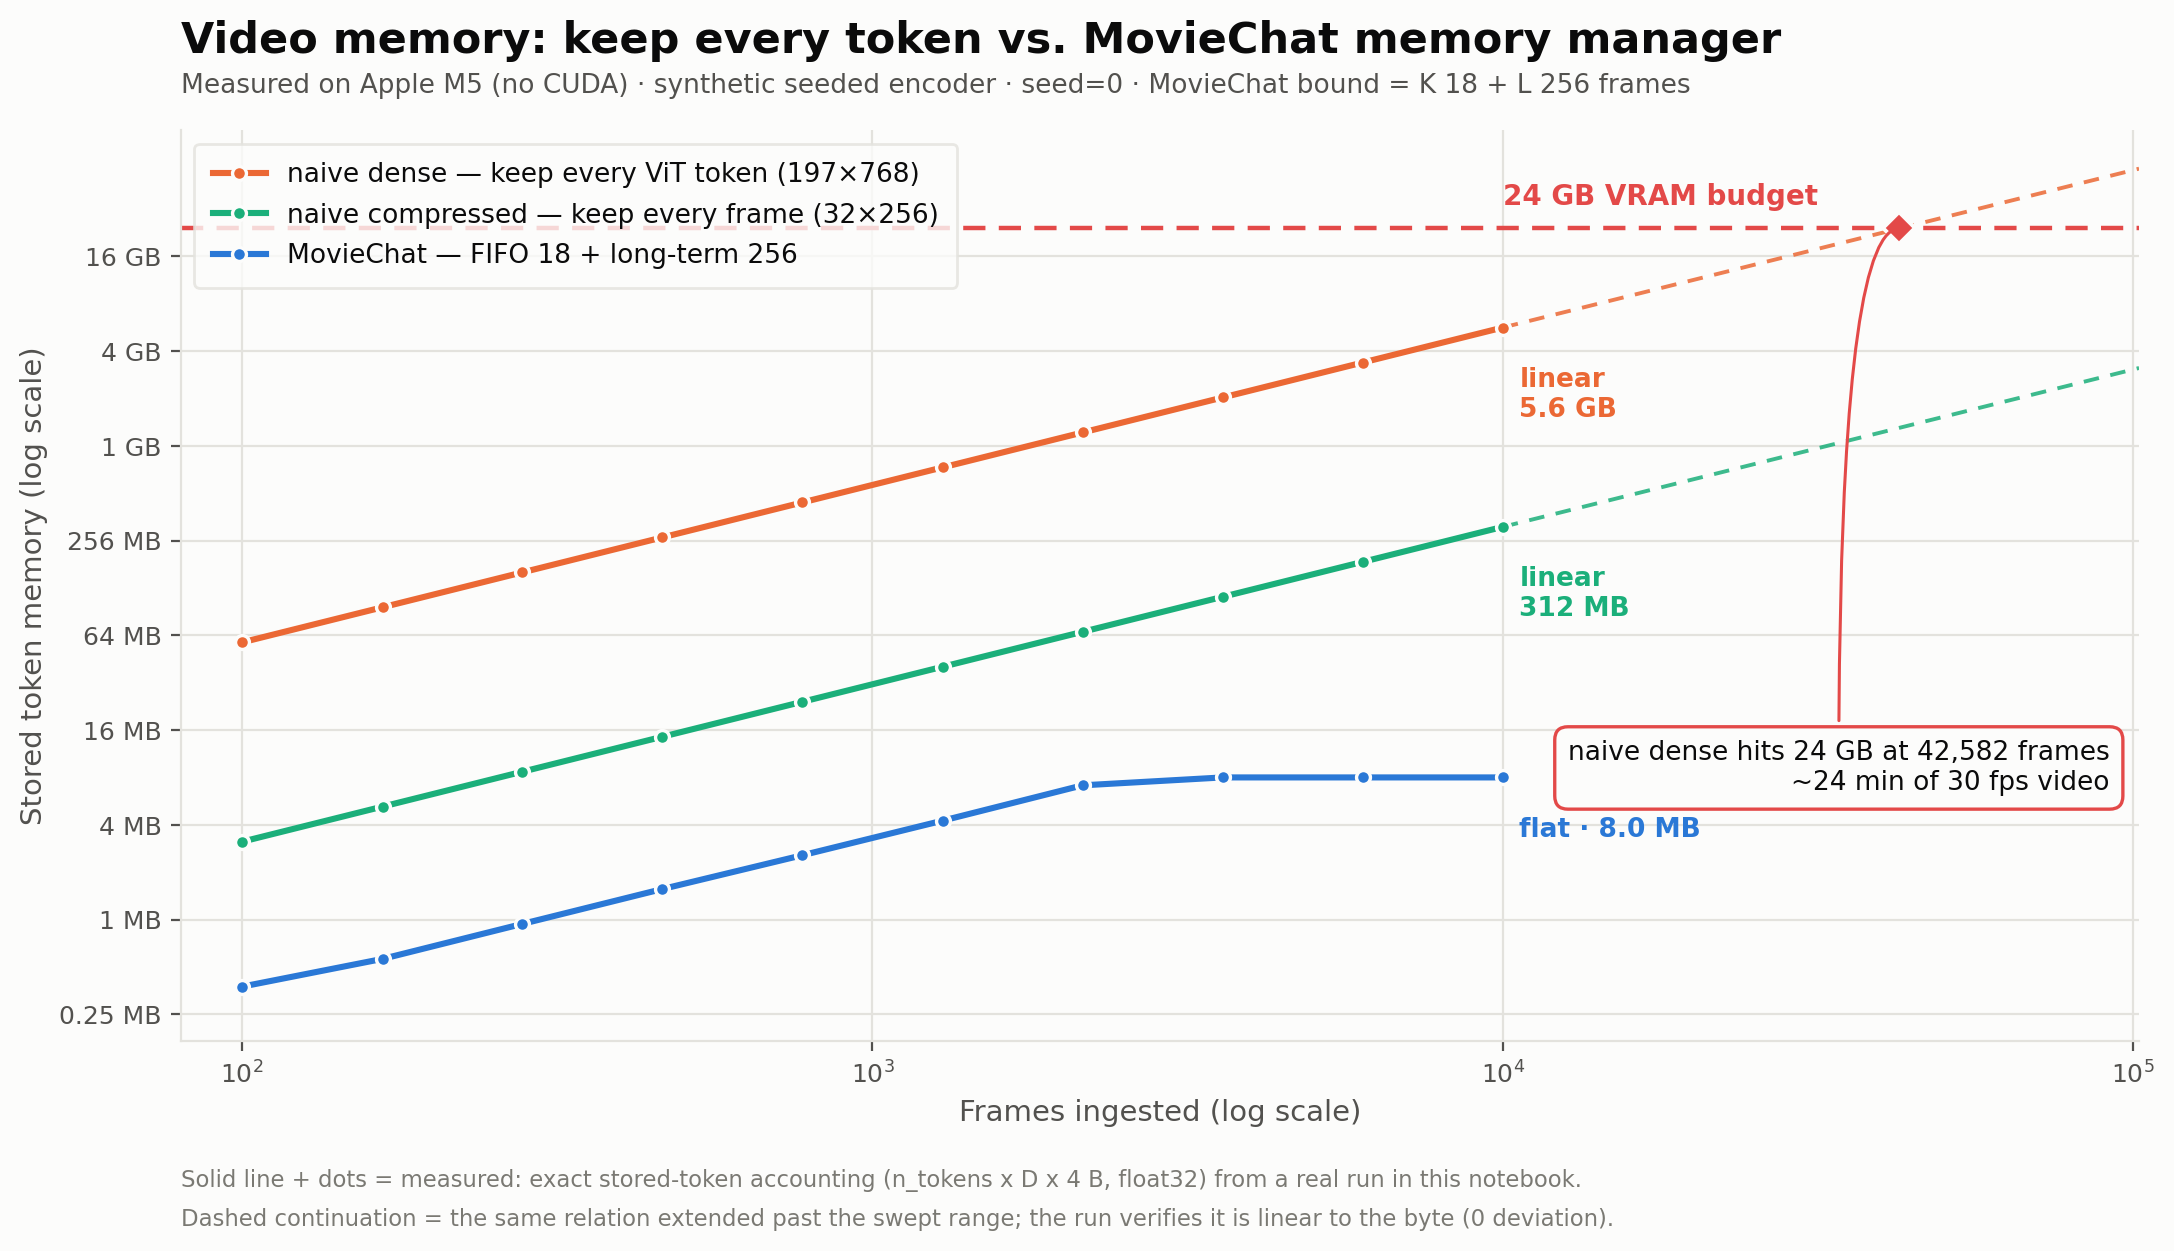

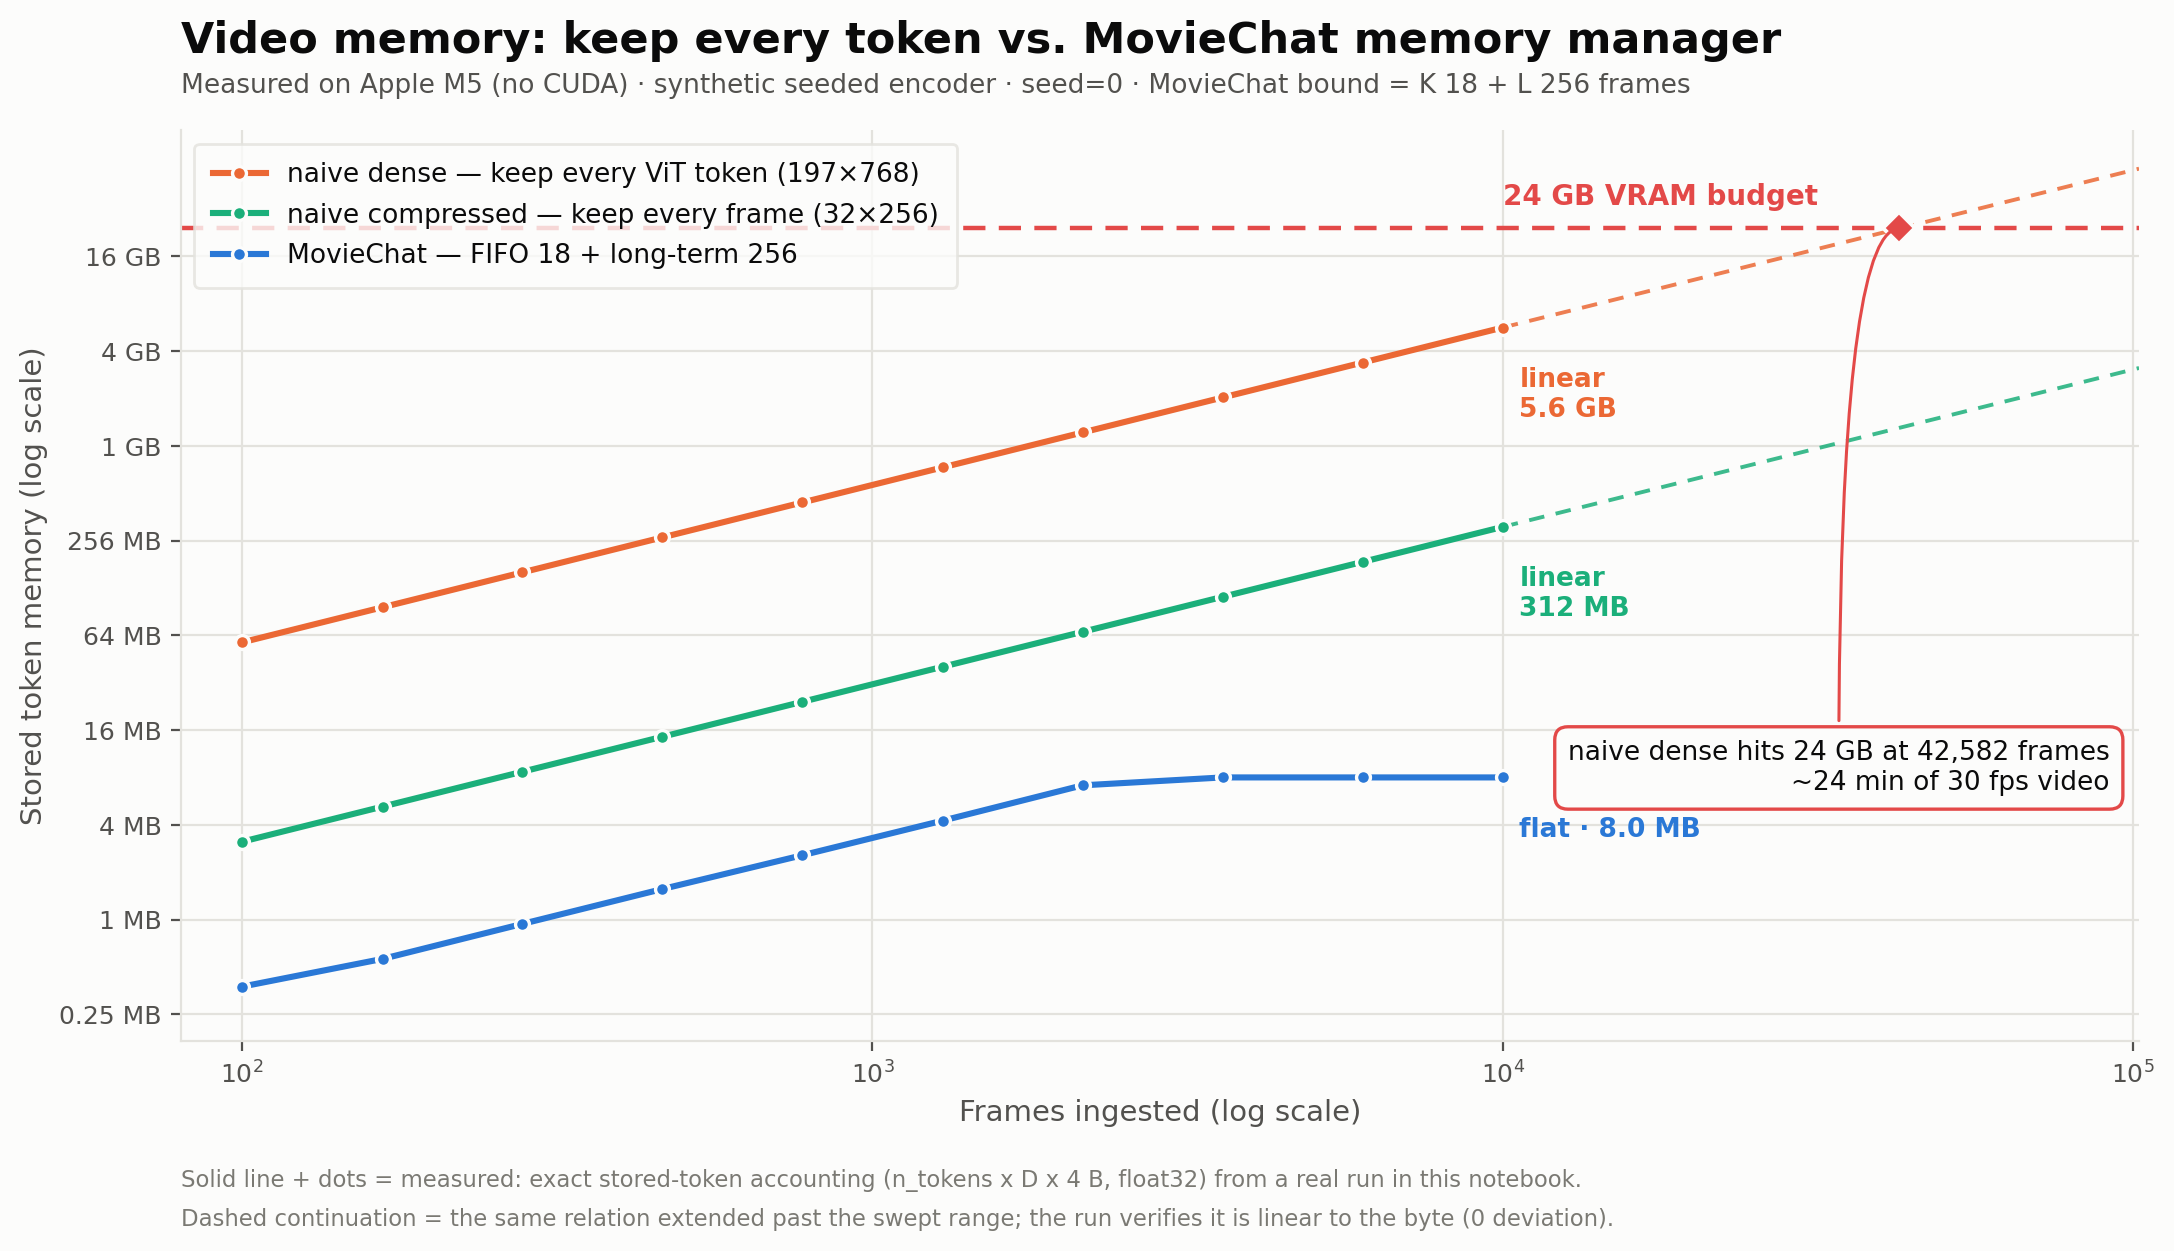

In [13]:
frames_x = [r["n_frames"] for r in rows]
series = {
    f"naive dense — keep every ViT token ({CFG['dense_tokens']}×{CFG['dense_dim']})": {
        "mb": [r["naive_dense"]["stored_mb"] for r in rows], "color": SERIES_2,
        "note": f"linear\n{last['naive_dense']['stored_mb']/1024:.1f} GB", "linear": True},
    f"naive compressed — keep every frame ({CFG['tokens_per_frame']}×{CFG['dim']})": {
        "mb": [r["naive_compressed"]["stored_mb"] for r in rows], "color": SERIES_3,
        "note": f"linear\n{last['naive_compressed']['stored_mb']:.0f} MB", "linear": True},
    f"MovieChat — FIFO {CFG['short_term_frames']} + long-term {CFG['long_term_frames']}": {
        "mb": [r["moviechat"]["stored_mb"] for r in rows], "color": SERIES_1,
        "note": f"flat · {last['moviechat']['stored_mb']:.1f} MB"},
}
crossing = (cross_dense, BUDGET_BYTES / MB,
            f"naive dense hits 24 GB at {cross_dense:,.0f} frames\n~{cross_dense/30/60:.0f} min of 30 fps video")

fig1 = plot_memory_vs_frames(
    frames_x, series, BUDGET_BYTES, crossing, FIGDIR / "fig_memory_vs_frames.png",
    subtitle=f"Measured on Apple M5 (no CUDA) · synthetic seeded encoder · seed={SEED} · "
             f"MovieChat bound = K {CFG['short_term_frames']} + L {CFG['long_term_frames']} frames")
fig1

**Result.** MovieChat saturates at **8.00 MB / 256 frames** by ~3,600 frames and does not move
after that — 10,000 frames costs exactly what 3,600 did. Both naive lines never stop growing.
At 10,000 frames the gap to the dense pipeline is **721×**.

## 7. Experiment 2 — does it merge the *right* frames?

Experiment 1 shows memory got smaller. That is not the interesting claim on its own — you can
always make memory smaller by throwing frames away. The claim worth testing is that the frames
it threw away were the **redundant** ones.

Setup: 320 frames, 8 visually distinct scenes of 40 frames each, encoded frame-by-frame by a
**pretrained ViT-B/16**. Within a scene, shapes drift a few pixels per frame plus mild sensor
noise, so adjacent frames are near-identical but never bit-identical. At a cut, everything
changes at once.

Two independent similarity signals are measured over all 319 adjacent pairs:

- **embedding cosine** — what the merge rule actually uses;
- **raw-pixel SSIM** — which the algorithm never sees.

Agreement between them is evidence rather than assumption.

In [14]:
def synth_scenes(n_frames=320, scene_length=40, size=224, seed=0):
    """Video of visually distinct scenes with slow within-scene motion.

    Returns (frames_uint8, cut_indices). Real pixels; generated content.
    """
    rng = np.random.default_rng(seed)
    frames = np.zeros((n_frames, size, size, 3), dtype=np.uint8)
    cuts = []
    yy, xx = np.mgrid[0:size, 0:size] / max(size - 1, 1)

    for s in range(int(np.ceil(n_frames / scene_length))):
        start = s * scene_length
        if start >= n_frames:
            break
        if start:
            cuts.append(start)

        c0 = rng.integers(25, 215, 3).astype(float)
        c1 = rng.integers(25, 215, 3).astype(float)
        ang = rng.uniform(0, np.pi)
        ramp = np.cos(ang) * xx + np.sin(ang) * yy
        ramp = (ramp - ramp.min()) / max(float(np.ptp(ramp)), 1e-9)
        bg = c0[None, None] * (1 - ramp[..., None]) + c1[None, None] * ramp[..., None]

        shapes = [dict(kind=rng.integers(0, 3), pos=rng.uniform(.2, .8, 2) * size,
                       vel=rng.uniform(-.9, .9, 2), rad=rng.uniform(.09, .20) * size,
                       col=rng.integers(0, 256, 3).tolist(), rot=rng.uniform(0, 180),
                       spin=rng.uniform(-1.5, 1.5))
                  for _ in range(int(rng.integers(3, 6)))]

        for t in range(start, min(start + scene_length, n_frames)):
            img, k = bg.copy(), t - start
            for sh in shapes:
                cx, cy = sh["pos"] + sh["vel"] * k
                cx = int(np.clip(cx, sh["rad"], size - sh["rad"]))
                cy = int(np.clip(cy, sh["rad"], size - sh["rad"]))
                r = int(sh["rad"])
                col = tuple(int(c) for c in sh["col"])
                if sh["kind"] == 0:
                    cv2.circle(img, (cx, cy), r, col, -1, lineType=cv2.LINE_AA)
                elif sh["kind"] == 1:
                    box = cv2.boxPoints(((cx, cy), (2 * r, 2 * r), sh["rot"] + sh["spin"] * k))
                    cv2.fillPoly(img, [np.int32(box)], col, lineType=cv2.LINE_AA)
                else:
                    a = np.deg2rad(sh["rot"] + sh["spin"] * k) + np.array([0, 2.094, 4.189])
                    pts = np.stack([cx + r * np.cos(a), cy + r * np.sin(a)], 1)
                    cv2.fillPoly(img, [np.int32(pts)], col, lineType=cv2.LINE_AA)
            img = img + rng.normal(0, 1.6, img.shape)     # keeps adjacent frames non-identical
            frames[t] = np.clip(img, 0, 255).astype(np.uint8)
    return frames, cuts


def load_video(path, max_frames, size=224, stride=1):
    """Decode up to max_frames RGB frames. Use this instead of synth_scenes for your own clip."""
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise RuntimeError(f"could not open video: {path}")
    out, i = [], 0
    while len(out) < max_frames:
        ok, bgr = cap.read()
        if not ok:
            break
        if i % stride == 0:
            out.append(cv2.resize(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), (size, size),
                                  interpolation=cv2.INTER_AREA))
        i += 1
    cap.release()
    if not out:
        raise RuntimeError(f"no frames decoded from {path}")
    return np.stack(out).astype(np.uint8)

### Configure and encode

`VIDEO_PATH = None` synthesises the clip. Point it at a file to run on your own footage.

Note `LONG_TERM_FRAMES = 16` here rather than the paper's 256: that cap is sized for
10k-frame movies and on a 320-frame clip it would never bind, so nothing would be
demonstrated. Everything else stays at paper defaults.

In [15]:
VIDEO_PATH        = None    # e.g. "clip.mp4"
N_FRAMES          = 320
SCENE_LENGTH      = 40
LONG_TERM_FRAMES  = 16      # lowered from 256 so the cap binds on a short clip
STRIP_COLS        = 16

if VIDEO_PATH:
    frames, true_cuts = load_video(VIDEO_PATH, N_FRAMES), None
    source = f"REAL video: {VIDEO_PATH} ({len(frames)} frames)"
else:
    frames, true_cuts = synth_scenes(N_FRAMES, SCENE_LENGTH, 224, SEED)
    source = (f"SYNTHETIC video (generated pixels, real encoder): {len(frames)} frames, "
              f"{SCENE_LENGTH}/scene, {len(true_cuts) + 1} scenes, cuts at {true_cuts}")
print(source)

encoder = RealEncoder(tokens_per_frame=CFG["tokens_per_frame"], dim=CFG["dim"], seed=SEED)
print(encoder.describe())

tokens = encoder.encode(frames, dense=False)
print("encoded:", tuple(tokens.shape), "(frames, tokens, dim)")

SYNTHETIC video (generated pixels, real encoder): 320 frames, 40/scene, 8 scenes, cuts at [40, 80, 120, 160, 200, 240, 280]


REAL encoder: timm vit_base_patch16_224 (pretrained), 224px, device=mps; dense=197x768, squeezed=32x256


encoded: (320, 32, 256) (frames, tokens, dim)


In [16]:
mem = MovieChatMemory(window=CFG["window"], short_term_frames=CFG["short_term_frames"],
                      tokens_per_frame=CFG["tokens_per_frame"], dim=CFG["dim"],
                      long_term_frames=LONG_TERM_FRAMES,
                      consolidation_length=CFG["consolidation_length"], track_merges=True)
print(mem.describe(), "\n")

mem.add_frames(tokens)
mem.finalize()

lt_sources  = [list(s) for s in mem.long_term.sources]
all_sources = mem.surviving_sources()
n_in, n_out = len(frames), len(all_sources)
ratio = n_in / n_out

print(f"Frames in                    : {n_in}")
print(f"Frames retained in memory    : {n_out}  (long-term {len(lt_sources)} + short-term {len(mem.short_term)})")
print(f"Compression ratio            : {ratio:.1f}x  "
      f"({token_bytes(n_in, CFG['tokens_per_frame'], CFG['dim']) / MB:.2f} MB -> {mem.stored_token_bytes / MB:.2f} MB)")
print(f"Consolidations / compactions : {mem.n_consolidations} / {mem.n_compactions}")
print(f"Merge operations logged      : {len(mem.merge_log)}")

moviechat: window=16, short-term=18x32, long-term cap=16, R_L=2, dim=256, reinit=False -> bounded at 34 frames (1.06 MiB) 

Frames in                    : 320
Frames retained in memory    : 16  (long-term 16 + short-term 0)
Compression ratio            : 20.0x  (10.00 MB -> 0.50 MB)
Consolidations / compactions : 17 / 9
Merge operations logged      : 304


In [17]:
cos_sims = adjacent_similarities([tokens[i] for i in range(len(tokens))])
gray = frames.astype(np.float64).mean(axis=-1)
ssim_vals = [float(ssim(gray[i], gray[i + 1], data_range=255.0)) for i in range(len(gray) - 1)]
merge_sims = [m.similarity for m in mem.merge_log]

print(f"Adjacent embedding cosine  : min {min(cos_sims):+.4f}  max {max(cos_sims):+.4f}  mean {np.mean(cos_sims):+.4f}")
print(f"Adjacent pixel SSIM        : min {min(ssim_vals):+.4f}  max {max(ssim_vals):+.4f}  mean {np.mean(ssim_vals):+.4f}")
print(f"Similarity at merges taken : min {min(merge_sims):+.4f}  max {max(merge_sims):+.4f}  mean {np.mean(merge_sims):+.4f}")

cross_scene, scenes_covered = [], []
if true_cuts:
    cut_pairs = [c - 1 for c in true_cuts]
    m = np.ones(len(cos_sims), bool); m[cut_pairs] = False
    cs, sv = np.array(cos_sims), np.array(ssim_vals)
    print(f"\n  within a scene : cosine {cs[m].mean():+.4f}   SSIM {sv[m].mean():+.4f}")
    print(f"  across a cut   : cosine {cs[~m].mean():+.4f}   SSIM {sv[~m].mean():+.4f}")
    print(f"  separation     : cosine {cs[m].mean() - cs[~m].mean():+.4f}   SSIM {sv[m].mean() - sv[~m].mean():+.4f}")

    # The decisive check: did any merge join frames from two different scenes?
    scene_of = lambda i: i // SCENE_LENGTH
    cross_scene = [(i, sorted({scene_of(j) for j in src})) for i, src in enumerate(all_sources)
                   if len({scene_of(j) for j in src}) > 1]
    scenes_covered = sorted({scene_of(j) for src in all_sources for j in src})
    print(f"\nRetained slots mixing frames from >1 scene: {len(cross_scene)} / {n_out}")
    for i, sc in cross_scene:
        print(f"    slot {i:>2} spans scenes {sc}")
    print(f"Scenes represented in memory: {len(scenes_covered)} / {len(true_cuts) + 1}")

Adjacent embedding cosine  : min +0.6523  max +0.9964  mean +0.9798
Adjacent pixel SSIM        : min +0.7428  max +0.9717  mean +0.9499
Similarity at merges taken : min +0.9077  max +0.9964  mean +0.9863

  within a scene : cosine +0.9860   SSIM +0.9528
  across a cut   : cosine +0.7009   SSIM +0.8187
  separation     : cosine +0.2851   SSIM +0.1342

Retained slots mixing frames from >1 scene: 0 / 16
Scenes represented in memory: 8 / 8


### The filmstrip

Each **OUT** cell is the size-weighted pixel average of the frames merged into that slot — the
pixel-space image of the token it holds. Within-scene motion shows up as blur; a cell that
straddled a cut would show two scenes ghosted together.

In [18]:
def plot_consolidation_filmstrip(orig_frames, orig_indices, kept_frames, kept_labels,
                                 cos_sims, ssim_vals, out_path, header="", footer="", cut_indices=None):
    ncols = max(len(orig_frames), len(kept_frames))
    width = min(1.16 * ncols + 1.6, 22)
    fig = plt.figure(figsize=(width, width * 0.30), dpi=190)
    fig.patch.set_facecolor(SURFACE)
    gs = fig.add_gridspec(3, ncols, height_ratios=[1, 1, 1.30], hspace=0.90, wspace=0.09,
                          left=0.045, right=0.955, top=0.760, bottom=0.115)

    row_axes = []
    for i, (img, idx) in enumerate(zip(orig_frames, orig_indices)):
        ax = fig.add_subplot(gs[0, i]); ax.imshow(img); ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_color(GRID)
        ax.set_title(f"f{idx}", color=TEXT_SECONDARY, fontsize=7.5, pad=2.5)
        if not i:
            row_axes.append(ax)

    for i, (img, lab) in enumerate(zip(kept_frames, kept_labels)):
        ax = fig.add_subplot(gs[1, i]); ax.imshow(img); ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_color(SERIES_1); sp.set_linewidth(1.6)
        ax.set_title(lab, color=SERIES_1, fontsize=7.5, pad=2.5, fontweight="bold")
        if not i:
            row_axes.append(ax)

    # Anchor row captions to real row geometry so they cannot land on the images.
    for ax, text, color in zip(row_axes,
                               ["IN  ·  original frames (subsampled)",
                                "OUT  ·  frames retained in MovieChat memory"],
                               [TEXT_PRIMARY, SERIES_1]):
        fig.text(0.045, ax.get_position().y1 + 0.055, text, color=color,
                 fontsize=11, fontweight="bold", ha="left", va="bottom")

    ax = fig.add_subplot(gs[2, :]); _base_style(ax)
    x = np.arange(1, len(cos_sims) + 1)
    if cut_indices:
        for j, c in enumerate(cut_indices):
            ax.axvline(c, color=TEXT_MUTED, linewidth=1.0, linestyle=(0, (2, 3)), zorder=1,
                       label="true scene cut" if not j else None)
    ax.plot(x, cos_sims, color=SERIES_1, linewidth=1.8, label="embedding cosine similarity", zorder=4)
    ax.plot(x, ssim_vals, color=SERIES_2, linewidth=1.8, label="raw-pixel SSIM", zorder=3)
    ax.annotate("embedding cosine", xy=(x[-1], cos_sims[-1]), xytext=(-4, 11),
                textcoords="offset points", color=SERIES_1, fontsize=9, fontweight="bold",
                va="bottom", ha="right", zorder=6)
    ax.annotate("pixel SSIM", xy=(x[-1], ssim_vals[-1]), xytext=(-4, -12),
                textcoords="offset points", color=SERIES_2, fontsize=9, fontweight="bold",
                va="top", ha="right", zorder=6)

    ax.set_ylim(min(min(cos_sims), min(ssim_vals)) - 0.045, 1.05)
    ax.set_xlim(0.5, len(cos_sims) + 0.5)
    ax.set_xlabel("adjacent frame pair (i, i+1)  —  every pair, not subsampled",
                  color=TEXT_SECONDARY, fontsize=10)
    ax.set_ylabel("similarity", color=TEXT_SECONDARY, fontsize=10)
    leg = ax.legend(loc="lower left", frameon=True, fontsize=8.5, facecolor=SURFACE,
                    edgecolor=GRID, ncols=3)
    leg.set_zorder(8)
    for t in leg.get_texts():
        t.set_color(TEXT_PRIMARY)

    fig.suptitle("Memory consolidation keeps scene changes and merges away redundancy",
                 color=TEXT_PRIMARY, fontsize=16, fontweight="bold", x=0.045, ha="left", y=0.975)
    fig.text(0.045, 0.925, header, color=TEXT_SECONDARY, fontsize=9.5, ha="left", va="center")
    fig.text(0.045, 0.028, footer, color=TEXT_MUTED, fontsize=8.2, ha="left")
    fig.savefig(out_path, facecolor=SURFACE)
    return fig

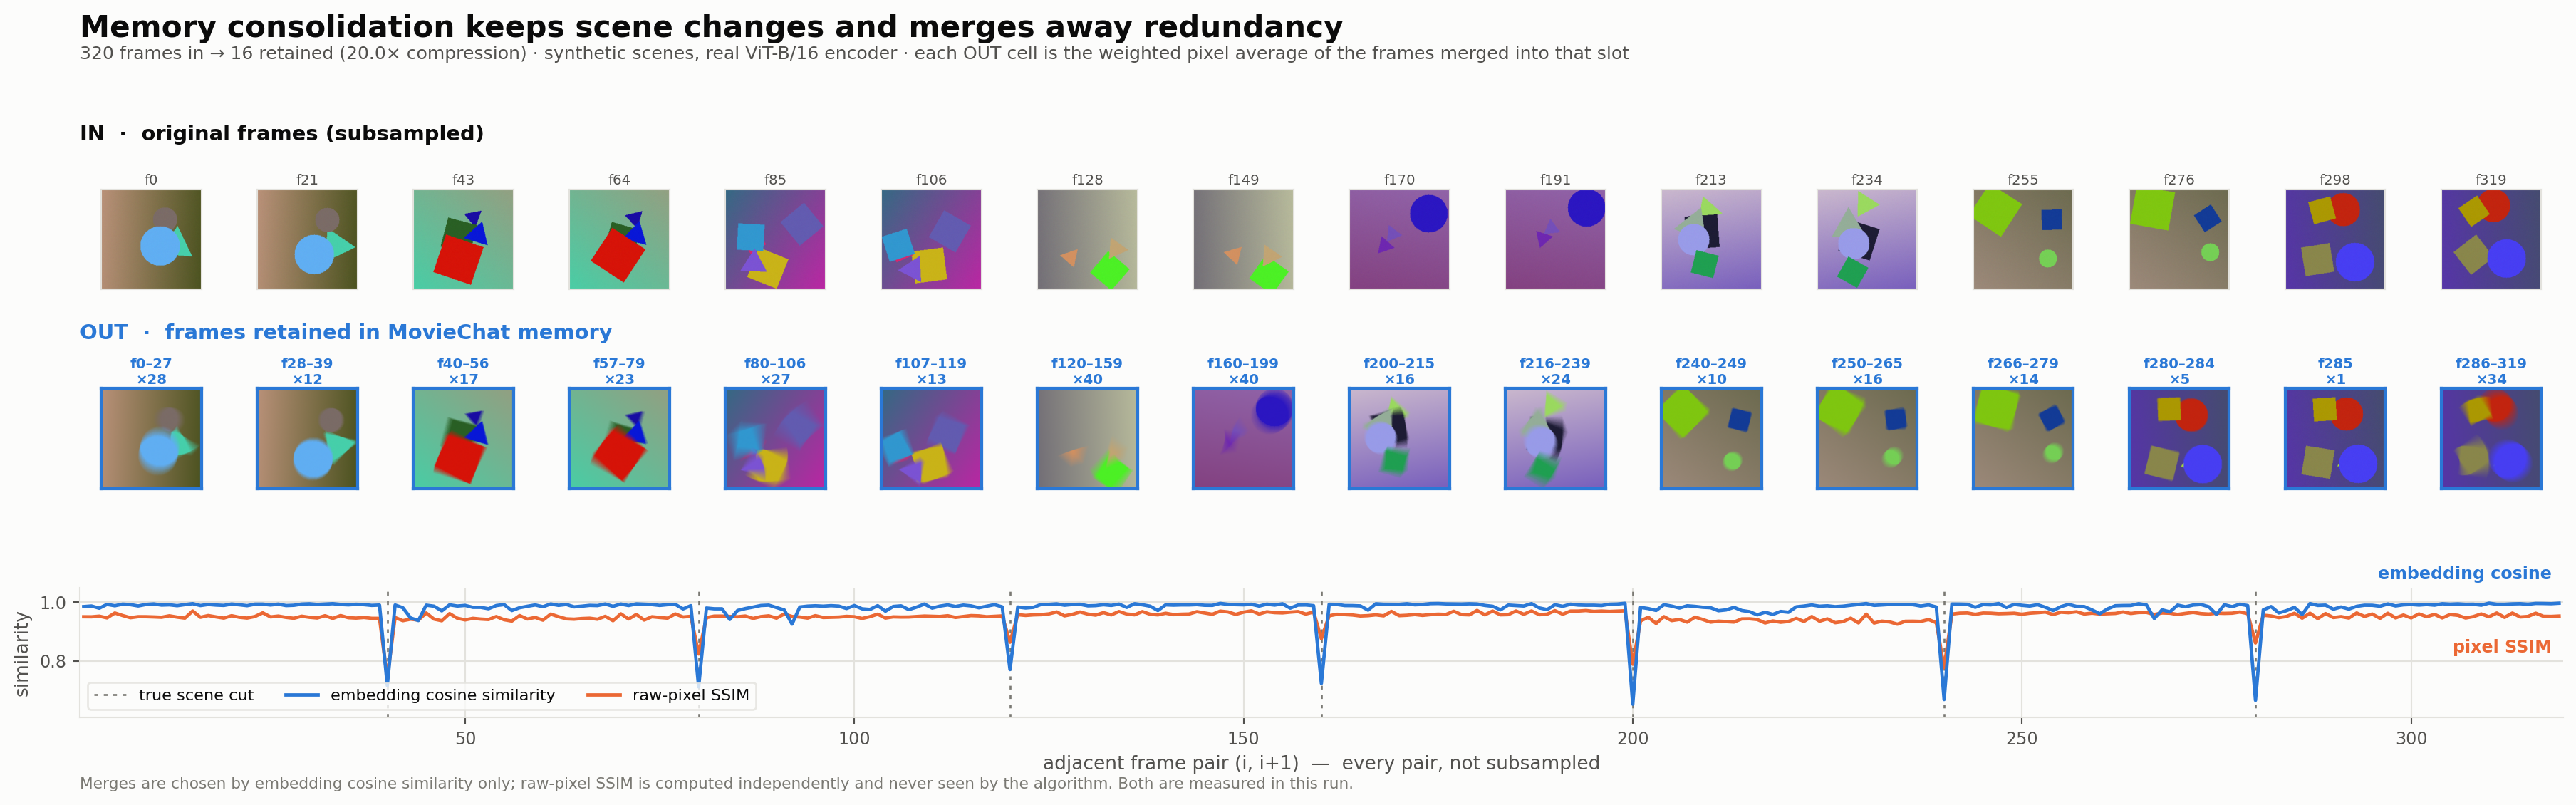

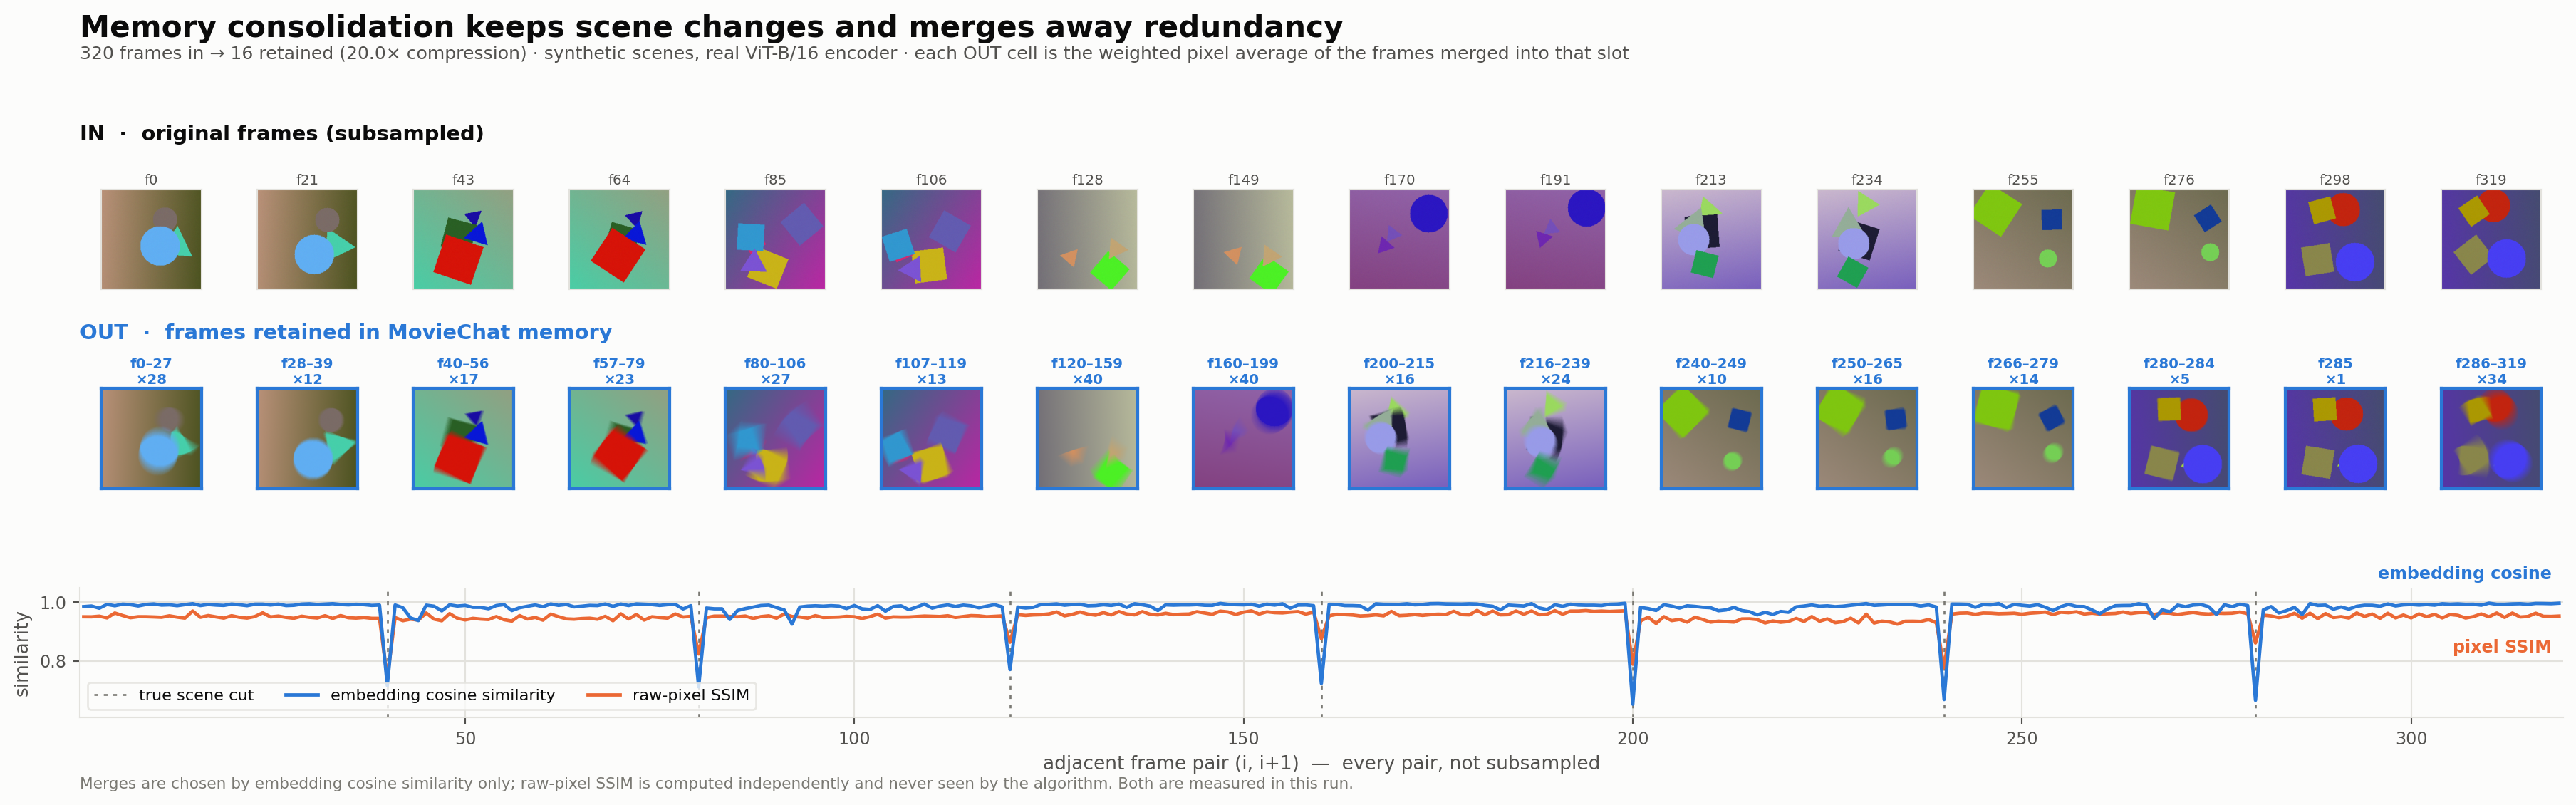

In [19]:
top_idx  = np.linspace(0, n_in - 1, min(STRIP_COLS, n_in)).round().astype(int).tolist()
top_imgs = [frames[i] for i in top_idx]

kept_imgs, kept_labels = [], []
for src in lt_sources:
    kept_imgs.append(np.clip(frames[src].astype(np.float64).mean(axis=0), 0, 255).astype(np.uint8))
    kept_labels.append(f"f{min(src)}–{max(src)}\n×{len(src)}" if len(src) > 1 else f"f{src[0]}\n×1")

fig2 = plot_consolidation_filmstrip(
    top_imgs, top_idx, kept_imgs, kept_labels, cos_sims, ssim_vals,
    FIGDIR / "fig_consolidation_filmstrip.png",
    header=(f"{n_in} frames in → {n_out} retained ({ratio:.1f}× compression) · "
            f"{'synthetic scenes, real ViT-B/16 encoder' if not VIDEO_PATH else Path(VIDEO_PATH).name} · "
            f"each OUT cell is the weighted pixel average of the frames merged into that slot"),
    footer=("Merges are chosen by embedding cosine similarity only; raw-pixel SSIM is computed "
            "independently and never seen by the algorithm. Both are measured in this run."),
    cut_indices=true_cuts)
fig2

## 8. Save raw numbers

Everything above, dumped to `results/` so the figures can be audited against the numbers
that produced them.

In [20]:
json.dump({"experiment": "scaling", "device": device_report(), "config": CFG, "rows": rows,
           "crossing_frames": {"naive_dense": cross_dense, "naive_compressed": cross_compr,
                               "moviechat": None},
           "moviechat_bound_frames": MC_BOUND, "moviechat_bound_mb": mc_bound_mb,
           "integrity": {"accounting_matches_tensors": ok_verify,
                         "naive_dense_linear_max_deviation_bytes": lin_dev,
                         "moviechat_within_bound": bool(max_mc <= MC_BOUND)}},
          open(RESDIR / "scaling.json", "w"), indent=2, default=str)

json.dump({"experiment": "consolidation", "device": device_report(), "source": source,
           "encoder": encoder.describe(), "frames_in": n_in, "frames_retained": n_out,
           "compression_ratio": ratio, "long_term_slots": lt_sources,
           "short_term_slots": [list(s) for s in mem.short_term.sources],
           "n_consolidations": mem.n_consolidations, "n_compactions": mem.n_compactions,
           "adjacent_cosine": cos_sims, "adjacent_pixel_ssim": ssim_vals,
           "merge_similarities": merge_sims, "true_cuts": true_cuts,
           "cross_scene_slots": [{"slot": i, "scenes": sc} for i, sc in cross_scene],
           "scenes_covered": scenes_covered},
          open(RESDIR / "consolidation.json", "w"), indent=2, default=str)

print("wrote results/scaling.json, results/consolidation.json")
print("wrote figures/fig_memory_vs_frames.png, figures/fig_consolidation_filmstrip.png")

wrote results/scaling.json, results/consolidation.json
wrote figures/fig_memory_vs_frames.png, figures/fig_consolidation_filmstrip.png


## 9. What's real, what's synthetic

Labelled explicitly, because it's the difference between a demo and a result.

| | Experiment 1 | Experiment 2 |
|---|---|---|
| encoder | **synthetic** — seeded token tensors, no pixels, no network | **real** — pretrained timm ViT-B/16, frame by frame |
| pixels | none | **synthetic** video (real pixels, generated content); set `VIDEO_PATH` for your own |
| memory manager | **real** — the same class in both | **real** |
| memory numbers | **measured**, exact accounting | **measured**, exact accounting |

Experiment 1 uses the synthetic encoder so a 10,000-frame sweep runs in ~20 s. The memory
manager under test is identical in both.

The 24 GB reference line is a **VRAM budget** for a typical 24 GB card, compared against
stored-token memory. Physical tensor allocation stops at a 2 GB guard because the host has
24 GB total — exact accounting continues past it.

---

## Takeaway

> Reproduced the core claim of MovieChat (arXiv:2307.16449) on a MacBook: a dense video
> pipeline that keeps every frame's tokens hits a 24 GB VRAM budget after 42,582 frames —
> about 24 minutes of 30 fps video. MovieChat's memory manager flatlines at 8 MB and never
> moves, no matter how long the video gets: 721× less at 10k frames.
>
> The trick is a fixed FIFO buffer plus a greedy merge of the most-similar adjacent frames —
> parameter-free, training-free, ~200 lines. On 320 frames across 8 scenes it compressed 20×
> while merging exactly zero pairs across a scene cut, and kept all 8 scenes.
>
> Long-video understanding wasn't blocked on a bigger context window. It was blocked on
> nobody throwing away the redundant frames.